In [6]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import warnings
warnings.filterwarnings('ignore')

# Path to your downloaded GeoTIFF
tif_path = '../data/raw/S2_Season1_BOA_Composite.tif'

with rasterio.open(tif_path) as src:
    print('CRS:', src.crs)
    print('Bands:', src.count)
    print('Resolution:', src.res)
    print('Shape:', src.shape)
    data = src.read()

print('Data shape:', data.shape)
print('Value range:', data.min(), '-', data.max())

CRS: EPSG:32642
Bands: 10
Resolution: (10.0, 10.0)
Shape: (1146, 1001)
Data shape: (10, 1146, 1001)
Value range: nan - nan


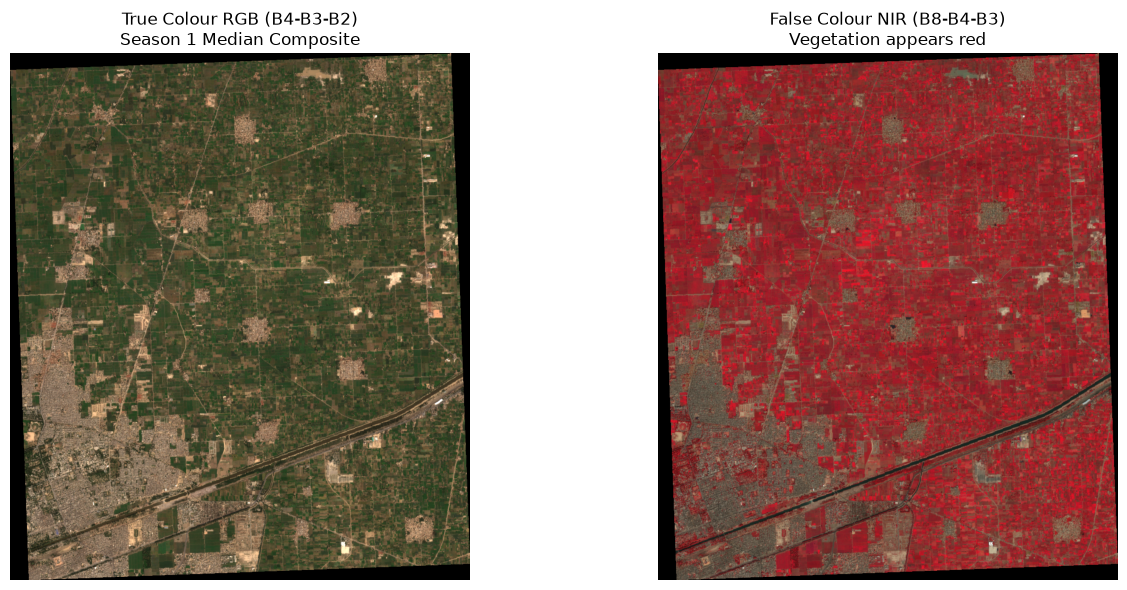

Saved!


In [7]:
# Band order: B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12
band_names = ['B2 Blue','B3 Green','B4 Red','B5 RedEdge1',
               'B6 RedEdge2','B7 RedEdge3','B8 NIR','B8A NIR narrow','B11 SWIR1','B12 SWIR2']

# RGB composite (B4=Red, B3=Green, B2=Blue)
rgb = np.stack([data[2], data[1], data[0]], axis=-1)
rgb = np.nan_to_num(rgb, nan=0.0)
rgb = np.clip(rgb / 0.3, 0, 1)

# False colour (NIR-Red-Green)
nrg = np.stack([data[6], data[2], data[1]], axis=-1)
nrg = np.nan_to_num(nrg, nan=0.0)
nrg = np.clip(nrg / 0.5, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(rgb)
axes[0].set_title('True Colour RGB (B4-B3-B2)\nSeason 1 Median Composite', fontsize=12)
axes[0].axis('off')

axes[1].imshow(nrg)
axes[1].set_title('False Colour NIR (B8-B4-B3)\nVegetation appears red', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../data/outputs/task1_composites.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

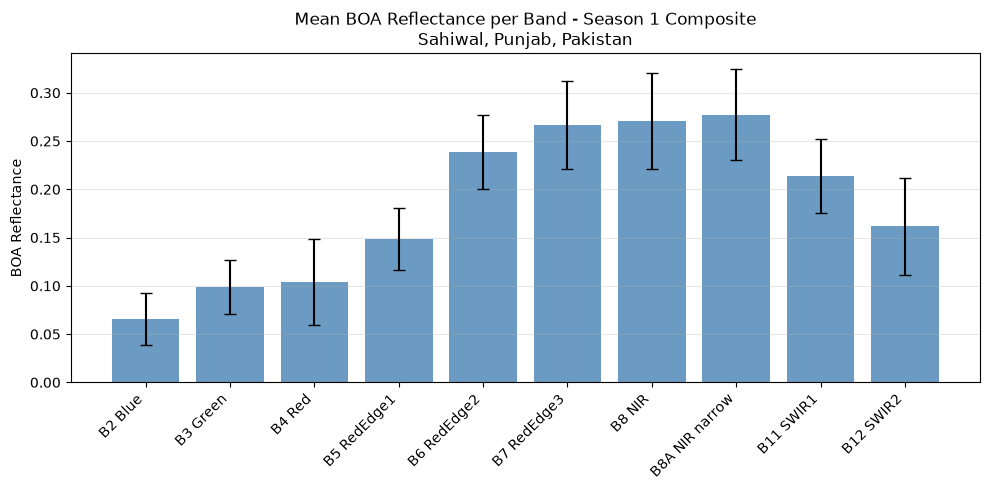

Saved!


In [8]:
# Mean reflectance per band
means = [np.nanmean(data[i]) for i in range(data.shape[0])]
stds  = [np.nanstd(data[i])  for i in range(data.shape[0])]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(band_names))
ax.bar(x, means, yerr=stds, capsize=4, color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(band_names, rotation=45, ha='right')
ax.set_ylabel('BOA Reflectance')
ax.set_title('Mean BOA Reflectance per Band - Season 1 Composite\nSahiwal, Punjab, Pakistan')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/outputs/task1_band_reflectance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')